Library Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from imblearn.over_sampling import SMOTE
from scipy.stats import pearsonr, spearmanr, kendalltau

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.exceptions import ConvergenceWarning

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

File connection

In [ ]:
file_link = 'https://drive.google.com/file/d/1ojFOXzuFMrio3EMX4VfP1gOU8OcSeJrQ/view?usp=sharing'
id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)

https://drive.google.com/uc?id=1ojFOXzuFMrio3EMX4VfP1gOU8OcSeJrQ


DATA PREPROCESSING

In [ ]:
X = df.drop("Quality_Label", axis=1)
y = df["Quality_Label"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [ ]:
from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Numerical imputation
num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# Convert categorical columns to dummy variables
X = pd.get_dummies(X, drop_first=True)

SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

TESTING 80-20

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

SHOWING 15 VALUES FROM DATASET

In [ ]:
df.head(15)

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
0,356.0,31,144,69.567047,0.467561,2,Yes,4,Medium
1,227.0,15,104,131.844422,0.795643,2,No,5,High
2,9674.0,47,141,118.729027,0.316839,5,No,1,High
3,6967.0,42,107,194.397155,0.971883,5,Yes,3,Low
4,7954.0,35,114,69.202293,0.559417,1,No,8,Medium
5,2305.0,38,120,164.299559,0.353860,5,No,6,Medium
6,8613.0,22,26,54.968552,0.355856,5,Yes,3,Medium
7,4479.0,5,149,88.060247,0.116470,7,Yes,7,High
8,8167.0,48,165,68.074588,0.723188,1,Yes,6,Low
9,6377.0,13,179,75.227914,0.798353,5,Yes,5,Medium


IMBALANCE GRAPH

Quality_Label
High      566
Low       533
Medium    501
Name: count, dtype: int64


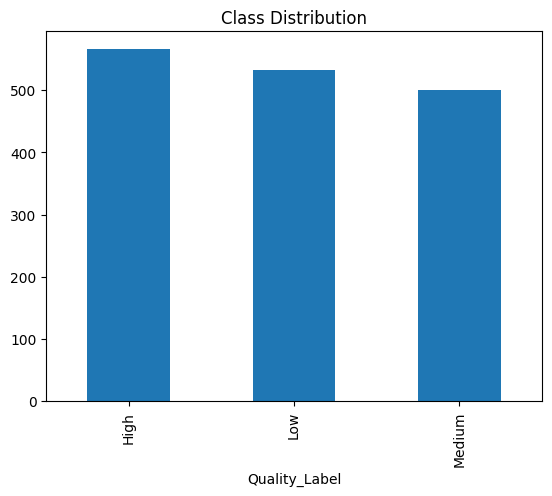

In [ ]:
# Simple code to check for imbalance
import pandas as pd
import matplotlib.pyplot as plt

class_counts = df['Quality_Label'].value_counts()
print(class_counts)
# Plotting
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.show()

NUMERICAL AND CATEGORICAL VALUES

In [ ]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 7 numerical features: 

['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn', 'Comment_Density', 'Num_Bugs', 'Code_Owner_Experience']


In [ ]:
#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 2 categorical features: 

['Has_Unit_Tests', 'Quality_Label']


DESCRIPTION OF NUMERICAL AND CATEGORICAL DATA

In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Lines_of_Code,1520.0,4939.269737,2867.248259,106.000000,2490.750000,4860.000000,7455.250000,9998.000000
Cyclomatic_Complexity,1600.0,25.076875,13.879621,1.000000,13.000000,25.000000,37.000000,49.000000
Num_Functions,1600.0,103.178125,55.503710,5.000000,56.000000,104.000000,152.000000,199.000000
Code_Churn,1520.0,102.572291,50.546329,-64.283310,67.509852,104.007452,138.619113,295.139936
Comment_Density,1520.0,0.549370,0.256137,0.101037,0.337596,0.542108,0.765766,0.999976
Num_Bugs,1600.0,2.934375,1.715928,0.000000,2.000000,3.000000,4.000000,10.000000
Code_Owner_Experience,1600.0,5.045000,2.559701,1.000000,3.000000,5.000000,7.000000,9.000000


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Has_Unit_Tests,1600,2,No,820
Quality_Label,1600,3,High,566


In [ ]:
num_rows, num_features = df.shape
print(f"Number of features: {num_features}")
print(f"Number of data points: {num_rows}")

Number of features: 9
Number of data points: 1600


NULL VALUES OVERVIEW

In [ ]:
df.isnull().sum()

,0
Lines_of_Code,80
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,80
Comment_Density,80
Num_Bugs,0
Has_Unit_Tests,0
Code_Owner_Experience,0
Quality_Label,0


ELBOW GRAPH

[12800.000000000013, 11195.859213879823, 10536.996216910198, 9898.04741163297, 9417.336168200718, 9025.654389341511, 8704.86052933592, 8377.9501932653, 8145.576337613804, 7927.9862779340765]


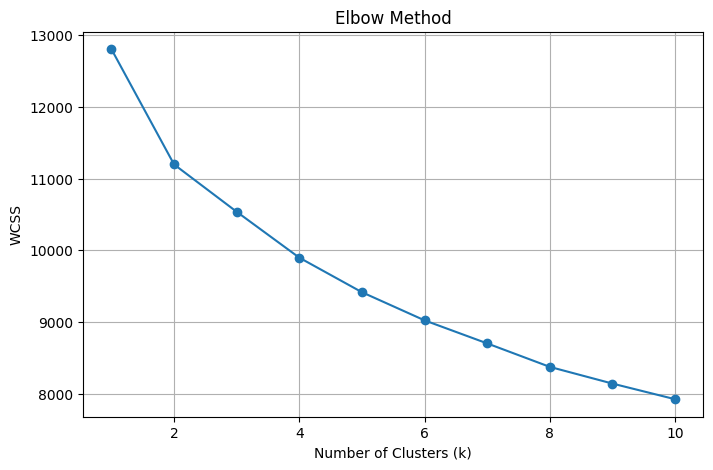

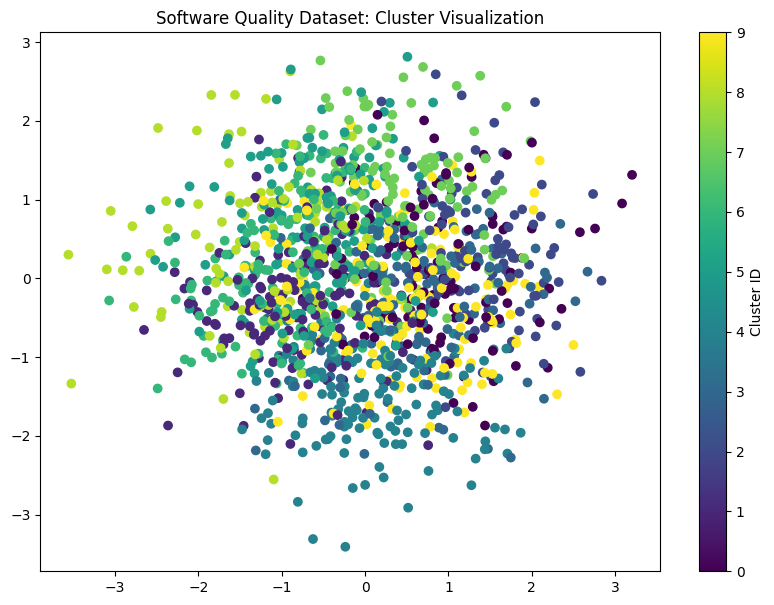

In [ ]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

data_to_cluster['Cluster'] = kmeans.fit_predict(scaled_data)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], c=data_to_cluster['Cluster'], cmap='viridis')
plt.title('Software Quality Dataset: Cluster Visualization')
plt.colorbar(label='Cluster ID')
plt.show()





K-MEANS CLUSTERING (n=3)

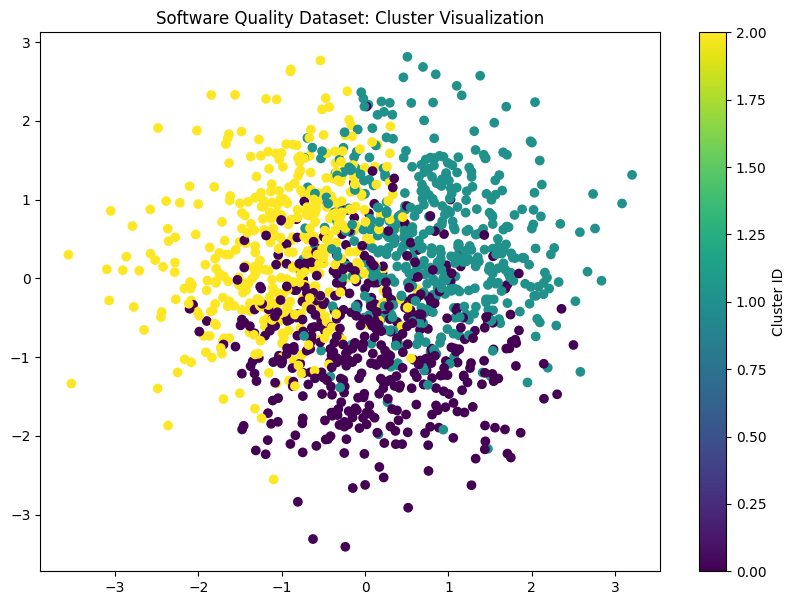

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Select numerical features for clustering
features = ['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn', 'Comment_Density', 'Num_Bugs', 'Code_Owner_Experience']
data_to_cluster = df[features].dropna()

# 2. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_cluster)

# 3. Run KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
data_to_cluster['Cluster'] = kmeans.fit_predict(scaled_data)

# 4. Visualize using PCA (Reducing 6 dimensions to 2 for plotting)
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], c=data_to_cluster['Cluster'], cmap='viridis')
plt.title('Software Quality Dataset: Cluster Visualization')
plt.colorbar(label='Cluster ID')
plt.show()

In [ ]:
# Check Unique Values
df.nunique()

,0
Lines_of_Code,1413
Cyclomatic_Complexity,49
Num_Functions,195
Code_Churn,1520
Comment_Density,1520
Num_Bugs,11
Has_Unit_Tests,2
Code_Owner_Experience,9
Quality_Label,3


Model Run Start

LOGISTIC REGRESSION

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=le_target.classes_))

Logistic Regression Accuracy: 0.3125
              precision    recall  f1-score   support

        High       0.39      0.43      0.41       127
         Low       0.24      0.22      0.23        99
      Medium       0.26      0.24      0.25        94

    accuracy                           0.31       320
   macro avg       0.30      0.30      0.30       320
weighted avg       0.31      0.31      0.31       320



NEURAL NETWORK

In [ ]:
from sklearn.neural_network import MLPClassifier

# Neural Network Model
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
# Train
nn_model.fit(X_train, y_train)
# Predict
y_pred_nn = nn_model.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn, target_names=le_target.classes_))

Neural Network Accuracy: 0.328125
              precision    recall  f1-score   support

        High       0.39      0.32      0.35       127
         Low       0.33      0.39      0.36        99
      Medium       0.26      0.27      0.26        94

    accuracy                           0.33       320
   macro avg       0.33      0.33      0.32       320
weighted avg       0.33      0.33      0.33       320



DECISION TREE

In [ ]:
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[str(cls) for cls in le_target.classes_]
    )
)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.3375

Classification Report:

              precision    recall  f1-score   support

        High       0.38      0.41      0.39       127
         Low       0.31      0.57      0.40        99
      Medium       0.00      0.00      0.00        94

    accuracy                           0.34       320
   macro avg       0.23      0.33      0.27       320
weighted avg       0.25      0.34      0.28       320


Confusion Matrix:

[[52 73  2]
 [41 56  2]
 [44 50  0]]


Histogram for numerical values

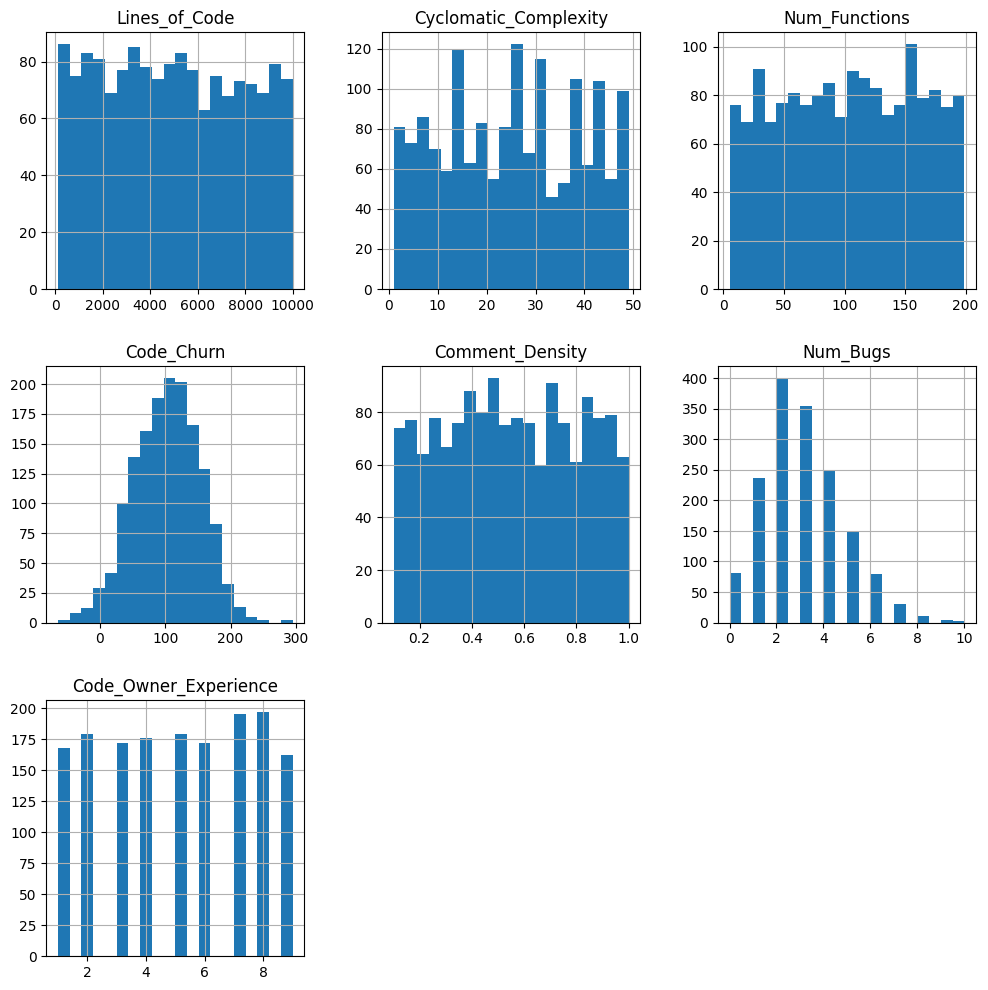

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

HEATMAP FOR CORRELATION MATRIX

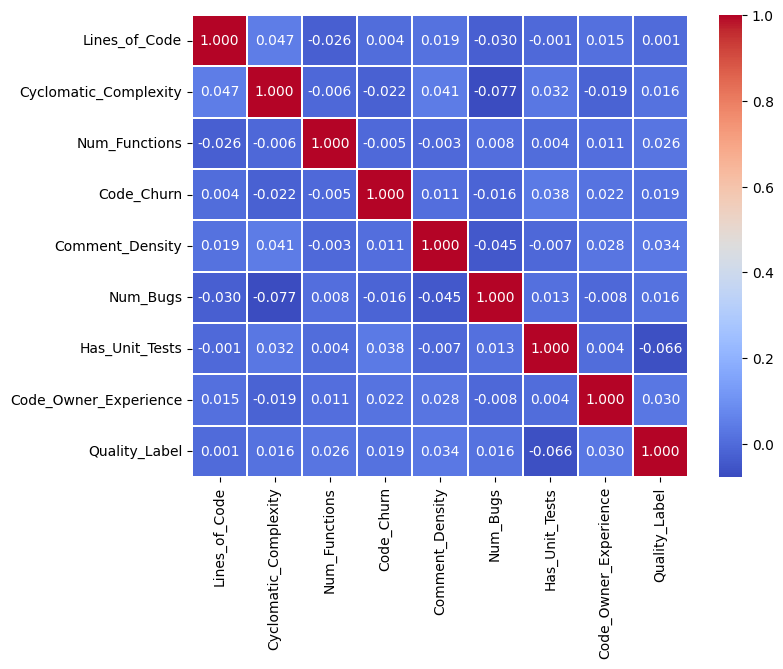

In [ ]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

ACCURACY COMPARISON

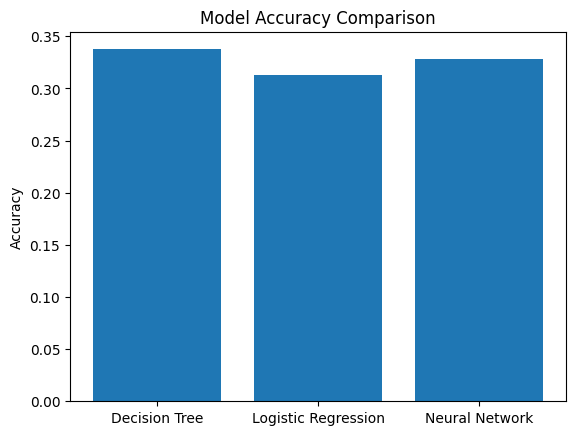

In [ ]:
models = {
    "Decision Tree": decision_tree_model,
    "Logistic Regression": log_model,
    "Neural Network": nn_model
}
accuracies = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, y_pred)

plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

ROC-AUC

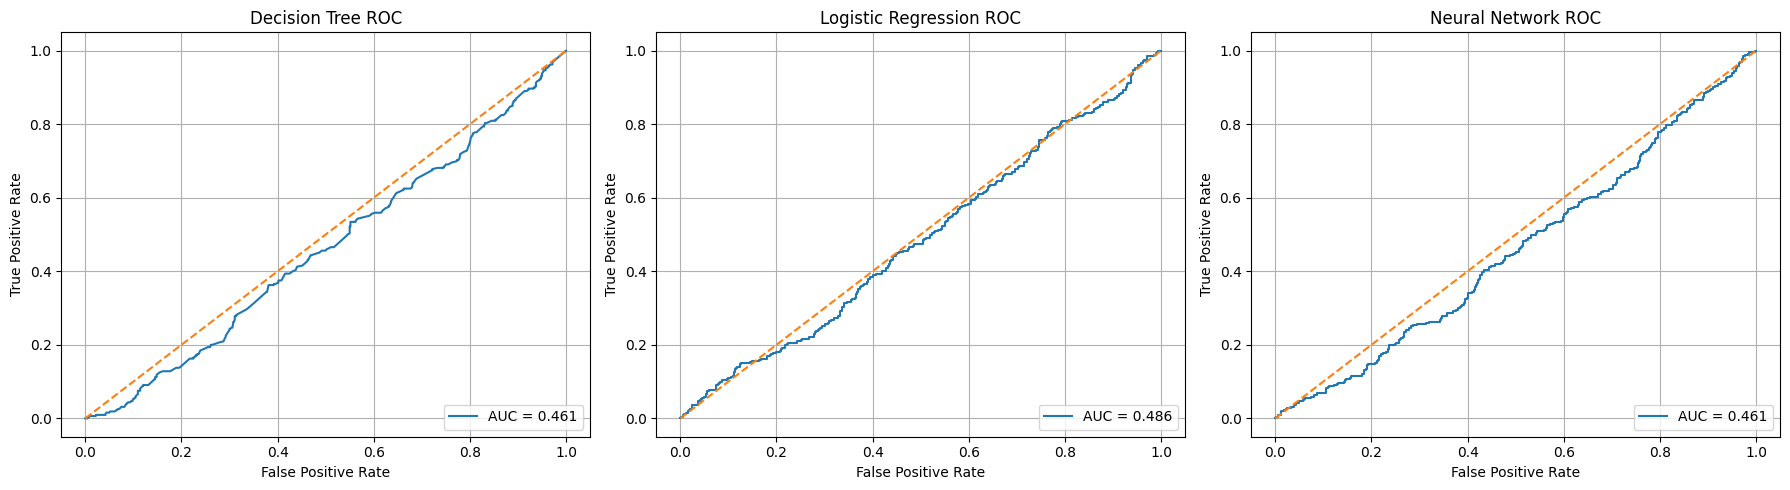

ROC-AUC Scores:
Decision Tree:       0.4605
Logistic Regression: 0.4863
Neural Network:      0.4607


In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
# Number of classes
n_classes = len(set(y_train))

# Convert multiclass labels to binary format
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# MODEL 1: Decision Tree
dt_model = OneVsRestClassifier(
    DecisionTreeClassifier(max_depth=5, random_state=42)
)

dt_model.fit(X_train, y_train)
y_score_dt = dt_model.predict_proba(X_test)

# MODEL 2: Logistic Regression
log_model = OneVsRestClassifier(
    LogisticRegression(max_iter=5000)
)

log_model.fit(X_train, y_train)
y_score_log = log_model.predict_proba(X_test)

# MODEL 3: Neural Network
nn_model = OneVsRestClassifier(
    MLPClassifier(
        hidden_layer_sizes=(64,32),
        max_iter=3000,
        random_state=42
    )
)

nn_model.fit(X_train, y_train)
y_score_nn = nn_model.predict_proba(X_test)

def get_micro_roc(y_true_bin, y_score):
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Calculate ROC
fpr_dt, tpr_dt, auc_dt = get_micro_roc(y_test_bin, y_score_dt)
fpr_log, tpr_log, auc_log = get_micro_roc(y_test_bin, y_score_log)
fpr_nn, tpr_nn, auc_nn = get_micro_roc(y_test_bin, y_score_nn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree Plot
axes[0].plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.3f}")
axes[0].plot([0,1], [0,1], linestyle="--")
axes[0].set_title("Decision Tree ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Logistic Regression Plot
axes[1].plot(fpr_log, tpr_log, label=f"AUC = {auc_log:.3f}")
axes[1].plot([0,1], [0,1], linestyle="--")
axes[1].set_title("Logistic Regression ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

# Neural Network Plot
axes[2].plot(fpr_nn, tpr_nn, label=f"AUC = {auc_nn:.3f}")
axes[2].plot([0,1], [0,1], linestyle="--")
axes[2].set_title("Neural Network ROC")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(loc="lower right")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("ROC-AUC Scores:")
print(f"Decision Tree:       {auc_dt:.4f}")
print(f"Logistic Regression: {auc_log:.4f}")
print(f"Neural Network:      {auc_nn:.4f}")

ADAM OPTIMIZER

Training Adam NN | epochs=300 | batch=32 | lr=0.001

  Epoch    1 | Loss: 1.0847 | Train Acc: 0.4016
  Epoch   50 | Loss: 0.3107 | Train Acc: 0.9180
  Epoch  100 | Loss: 0.0374 | Train Acc: 1.0000
  Epoch  150 | Loss: 0.0088 | Train Acc: 1.0000
  Epoch  200 | Loss: 0.0051 | Train Acc: 0.9992
  Epoch  250 | Loss: 0.0034 | Train Acc: 1.0000
  Epoch  300 | Loss: 0.0037 | Train Acc: 1.0000

  ADAM OPTIMIZER — TEST SET RESULTS
  Accuracy: 0.3281

Classification Report:
              precision    recall  f1-score   support

        High       0.39      0.32      0.35       127
         Low       0.34      0.36      0.35        99
      Medium       0.26      0.30      0.28        94

    accuracy                           0.33       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.33      0.33      0.33       320

Confusion Matrix:
[[41 39 47]
 [30 36 33]
 [35 31 28]]


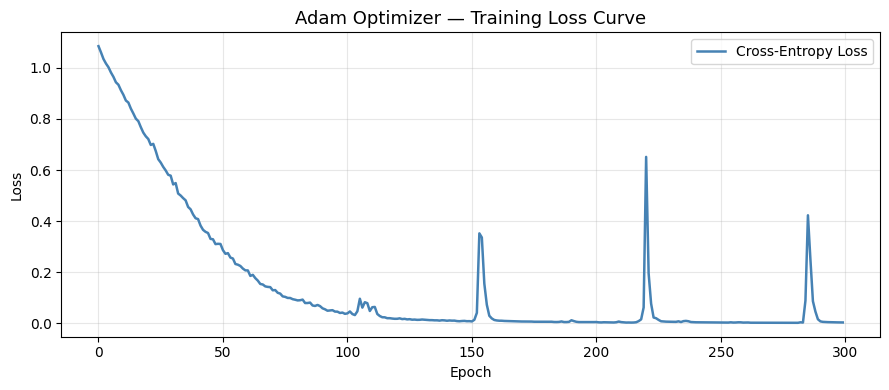


  SKLEARN MLP (Adam solver) — TEST SET RESULTS
  Accuracy: 0.3219

Classification Report:
              precision    recall  f1-score   support

        High       0.36      0.30      0.33       127
         Low       0.34      0.41      0.38        99
      Medium       0.25      0.26      0.25        94

    accuracy                           0.32       320
   macro avg       0.32      0.32      0.32       320
weighted avg       0.32      0.32      0.32       320



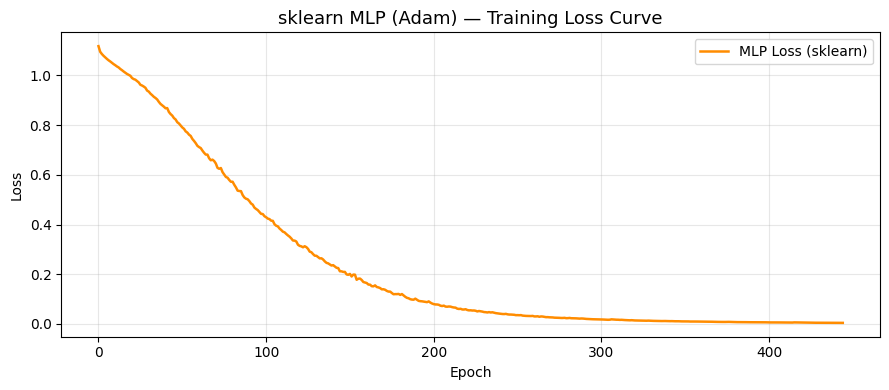

In [ ]:
class AdamOptimizer:
    def __init__(
        self,
        layer_sizes,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        epochs=500,
        batch_size=32,
        random_state=42
    ):
        self.layer_sizes   = layer_sizes
        self.lr            = learning_rate
        self.beta1         = beta1
        self.beta2         = beta2
        self.epsilon       = epsilon
        self.epochs        = epochs
        self.batch_size    = batch_size
        self.loss_history  = []
        np.random.seed(random_state)
        self.weights = []
        self.biases  = []
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) \
                * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)
        self.m_w = [np.zeros_like(w) for w in self.weights]
        self.v_w = [np.zeros_like(w) for w in self.weights]
        self.m_b = [np.zeros_like(b) for b in self.biases]
        self.v_b = [np.zeros_like(b) for b in self.biases]
        self.t   = 0
    def _relu(self, z):
        return np.maximum(0, z)

    def _relu_deriv(self, z):
        return (z > 0).astype(float)

    def _softmax(self, z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    def _forward(self, X):
        self._activations = [X]
        self._zs = []
        a = X
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            z = a @ w + b
            self._zs.append(z)
            if i < len(self.weights) - 1:
                a = self._relu(z)
            else:
                a = self._softmax(z)
            self._activations.append(a)
        return self._activations[-1]
    def _loss(self, y_pred, y_true_onehot):
        n = y_true_onehot.shape[0]
        log_likelihood = -np.sum(y_true_onehot * np.log(y_pred + 1e-15))
        return log_likelihood / n
    def _backward(self, y_true_onehot):
        n = y_true_onehot.shape[0]
        grads_w = []
        grads_b = []
        delta = (self._activations[-1] - y_true_onehot) / n

        for i in reversed(range(len(self.weights))):
            dw = self._activations[i].T @ delta
            db = np.sum(delta, axis=0, keepdims=True)
            grads_w.insert(0, dw)
            grads_b.insert(0, db)

            if i > 0:
                delta = (delta @ self.weights[i].T) * self._relu_deriv(self._zs[i - 1])

        return grads_w, grads_b
    def _adam_update(self, grads_w, grads_b):
        self.t += 1
        for i in range(len(self.weights)):
            self.m_w[i] = self.beta1 * self.m_w[i] + (1 - self.beta1) * grads_w[i]
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * grads_b[i]

            self.v_w[i] = self.beta2 * self.v_w[i] + (1 - self.beta2) * grads_w[i] ** 2
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * grads_b[i] ** 2

            m_w_hat = self.m_w[i] / (1 - self.beta1 ** self.t)
            m_b_hat = self.m_b[i] / (1 - self.beta1 ** self.t)
            v_w_hat = self.v_w[i] / (1 - self.beta2 ** self.t)
            v_b_hat = self.v_b[i] / (1 - self.beta2 ** self.t)

            self.weights[i] -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + self.epsilon)
            self.biases[i]  -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + self.epsilon)

    def fit(self, X, y):
        n_classes = len(np.unique(y))
        y_onehot = np.eye(n_classes)[y]

        n_samples = X.shape[0]
        print(f"Training Adam NN | epochs={self.epochs} | batch={self.batch_size} | lr={self.lr}\n")

        for epoch in range(1, self.epochs + 1):
            idx = np.random.permutation(n_samples)
            X_shuf, y_shuf = X[idx], y_onehot[idx]

            for start in range(0, n_samples, self.batch_size):
                X_batch = X_shuf[start: start + self.batch_size]
                y_batch = y_shuf[start: start + self.batch_size]

                y_pred = self._forward(X_batch)
                grads_w, grads_b = self._backward(y_batch)
                self._adam_update(grads_w, grads_b)

            y_pred_full = self._forward(X)
            loss = self._loss(y_pred_full, y_onehot)
            self.loss_history.append(loss)

            if epoch % 50 == 0 or epoch == 1:
                train_acc = accuracy_score(y, self.predict(X))
                print(f"  Epoch {epoch:>4} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

        return self

    def predict_proba(self, X):
        return self._forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

n_features = X_train.shape[1]
n_classes  = len(np.unique(y_train))

adam_model = AdamOptimizer(
    layer_sizes   = [n_features, 128, 64, 32, n_classes],
    learning_rate = 0.001,
    beta1         = 0.9,
    beta2         = 0.999,
    epsilon       = 1e-8,
    epochs        = 300,
    batch_size    = 32,
    random_state  = 42
)

adam_model.fit(X_train, y_train)

y_pred_adam = adam_model.predict(X_test)

print("\n" + "="*55)
print("  ADAM OPTIMIZER — TEST SET RESULTS")
print("="*55)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_adam):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_adam, target_names=[str(c) for c in le_target.classes_]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adam))


plt.figure(figsize=(9, 4))
plt.plot(adam_model.loss_history, color='steelblue', linewidth=1.8, label='Cross-Entropy Loss')
plt.title("Adam Optimizer — Training Loss Curve", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

from sklearn.neural_network import MLPClassifier

mlp_adam = MLPClassifier(
    hidden_layer_sizes = (128, 64, 32),
    activation         = 'relu',
    solver             = 'adam',
    learning_rate_init = 0.001,
    beta_1             = 0.9,
    beta_2             = 0.999,
    epsilon            = 1e-8,
    max_iter           = 1000,
    random_state       = 42
)

mlp_adam.fit(X_train, y_train)
y_pred_mlp = mlp_adam.predict(X_test)

print("\n" + "="*55)
print("  SKLEARN MLP (Adam solver) — TEST SET RESULTS")
print("="*55)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le_target.classes_))

# Loss curve for sklearn MLP
plt.figure(figsize=(9, 4))
plt.plot(mlp_adam.loss_curve_, color='darkorange', linewidth=1.8, label='MLP Loss (sklearn)')
plt.title("sklearn MLP (Adam) — Training Loss Curve", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

CONFUSION MATRIX

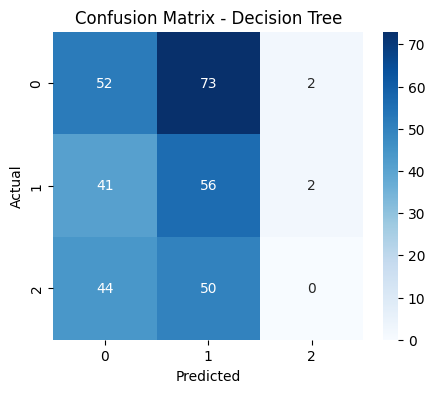

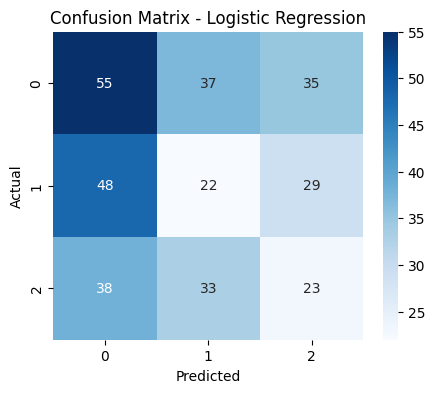

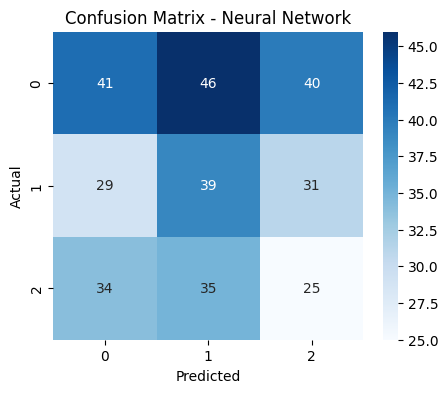

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

PRECISION-RECALL COMPARISON

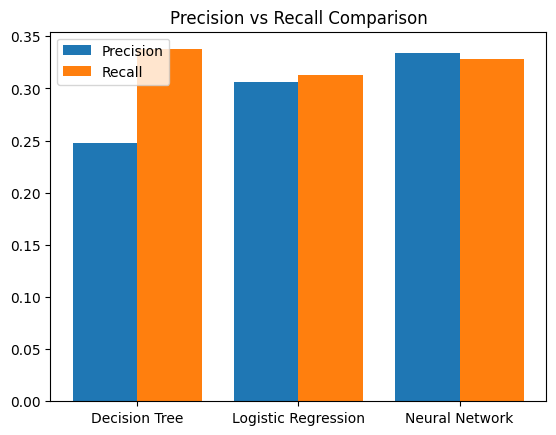

In [ ]:
precision_scores = {}
recall_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    precision_scores[name] = precision_score(y_test, y_pred, average='weighted')
    recall_scores[name] = recall_score(y_test, y_pred, average='weighted')
x = np.arange(len(models))

plt.bar(x - 0.2, precision_scores.values(), 0.4, label='Precision')
plt.bar(x + 0.2, recall_scores.values(), 0.4, label='Recall')

plt.xticks(x, precision_scores.keys())
plt.title("Precision vs Recall Comparison")
plt.legend()
plt.show()

AUC COMPARISON

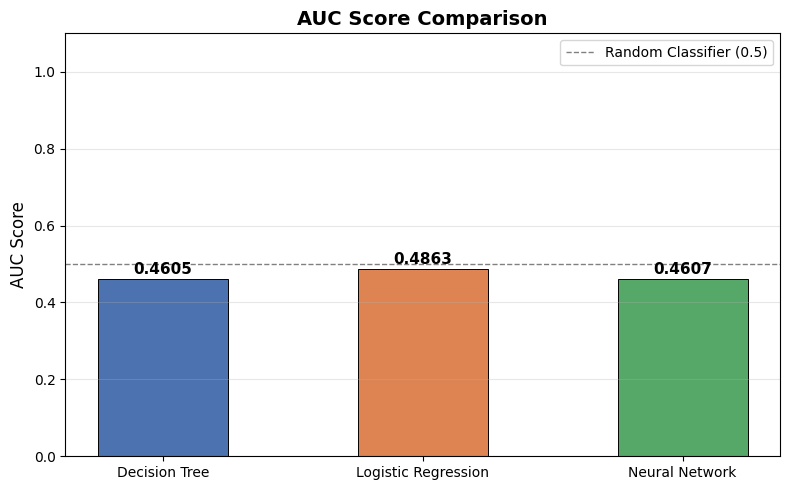

In [ ]:
# AUC Score Comparison Bar Plot
model_names = ['Decision Tree', 'Logistic Regression', 'Neural Network']
auc_scores  = [auc_dt, auc_log, auc_nn]
colors      = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, auc_scores, color=colors, width=0.5, edgecolor='black', linewidth=0.7)

# Annotate values on top of bars
for bar, score in zip(bars, auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('AUC Score Comparison', fontsize=14, fontweight='bold')
plt.ylabel('AUC Score', fontsize=12)
plt.ylim(0, 1.1)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Random Classifier (0.5)')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()